<a href="https://colab.research.google.com/github/shubham12309/macro-regime-allocation/blob/main/Portfolio_asset_allocation_regime.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Environment Setup & Imports
We install and import necessary libraries for data processing, financial econometrics, and plotting.

In [ ]:
# Install extra libraries for financial data and FRED macroeconomic API
!pip install yfinance pandas_datareader statsmodels scipy matplotlib seaborn --quiet

import os
import datetime
import numpy as np
import pandas as pd
import yfinance as yf
import pandas_datareader.data as web
import statsmodels.api as sm
from statsmodels.tsa.regime_switching.markov_autoregression import MarkovAutoregression
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configure plotting style and suppress minor warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("[SUCCESS] Environment configured and libraries loaded.")

[SUCCESS] Environment configured and libraries loaded.


# 2. Data Pipeline (Market Prices & FRED Macro Data)
We pull historical prices for Equities (S&P 500), Bonds (TLT), and Gold (GLD) via Yahoo Finance,
alongside the 10Y-2Y Treasury Yield Spread from Federal Reserve Economic Data (FRED).
Data is converted to monthly log returns to align frequencies.

In [ ]:
start_date = "2008-01-01"
end_date = "2026-01-01"

print("Fetching Market Asset Prices and FRED Macro Factors...")

# Define tickers for Equity, Bonds, and Gold
market_tickers = {'Equity': '^GSPC', 'Bonds': 'TLT', 'Gold': 'GLD'}
ticker_list = list(market_tickers.values())

# Download data and safely extract 'Adj Close' or 'Close'
df_raw = yf.download(ticker_list, start=start_date, end=end_date, auto_adjust=False)

if 'Adj Close' in df_raw.columns.get_level_values(0):
    prices = df_raw['Adj Close']
else:
    prices = df_raw['Close']

# Rename columns from ticker symbols to asset class names
prices = prices.rename(columns={v: k for k, v in market_tickers.items()})

# Resample daily prices to monthly end-of-period log returns
monthly_prices = prices.resample('M').last()
returns = np.log(monthly_prices / monthly_prices.shift(1)).dropna()

# Fetch 10Y-2Y Yield Spread from FRED
try:
    start_dt = datetime.datetime.strptime(start_date, "%Y-%m-%d")
    end_dt = datetime.datetime.strptime(end_date, "%Y-%m-%d")
    yield_spread = web.DataReader('T10Y2Y', 'fred', start_dt, end_dt)

    macro_monthly = yield_spread.resample('M').last().ffill()
    macro_monthly.columns = ['Yield_Spread']

    df_data = returns.join(macro_monthly, how='inner').dropna()
    print(" -> Market and FRED macro data successfully combined.")
except Exception as e:
    print(f" -> FRED API issue ({e}). Generated fallback yield spread proxy.")
    returns['Yield_Spread'] = np.random.normal(0.8, 0.5, len(returns))
    df_data = returns.dropna()

# Display first 5 rows
df_data.head()

[*********************100%***********************]  3 of 3 completed

Fetching Market Asset Prices and FRED Macro Factors...
 -> Market and FRED macro data successfully combined.


,Gold,Bonds,Equity,Yield_Spread
2008-02-29,0.050976,-0.004562,-0.035380,1.88
2008-03-31,-0.061867,0.021163,-0.005977,1.83
2008-04-30,-0.042478,-0.025178,0.046451,1.48
2008-05-31,0.009190,-0.027251,0.010618,1.40
2008-06-30,0.044178,0.026191,-0.089884,1.36


# 3. Stationarity & Econometric Diagnostics
To ensure time-series validity and prevent spurious regression, we run the Augmented Dickey-Fuller (ADF) test.
A p-value < 0.05 indicates the series is stationary.

In [ ]:
print("--- Augmented Dickey-Fuller (ADF) Stationarity Tests ---")

for col in ['Equity', 'Bonds', 'Gold', 'Yield_Spread']:
    res = adfuller(df_data[col].dropna())
    stat, p_val = res[0], res[1]
    status = "Stationary (p < 0.05)" if p_val < 0.05 else "Non-Stationary"
    print(f"{col:15s} | ADF Stat: {stat:7.3f} | p-value: {p_val:6.4f} | {status}")

--- Augmented Dickey-Fuller (ADF) Stationarity Tests ---
Equity          | ADF Stat: -10.996 | p-value: 0.0000 | Stationary (p < 0.05)
Bonds           | ADF Stat: -13.628 | p-value: 0.0000 | Stationary (p < 0.05)
Gold            | ADF Stat: -16.214 | p-value: 0.0000 | Stationary (p < 0.05)
Yield_Spread    | ADF Stat:  -1.555 | p-value: 0.5063 | Non-Stationary


# 4. Markov-Switching Regime Model Estimation
We fit a 2-State Markov-Switching Autoregressive model on stock returns using the yield curve spread as an exogenous driver.
We classify the states into Low-Volatility (Expansion) and High-Volatility (Contraction) regimes.

Low-Volatility Regime: State 0 (Monthly Vol: 2.80%)
High-Volatility Regime: State 1 (Monthly Vol: 4.47%)


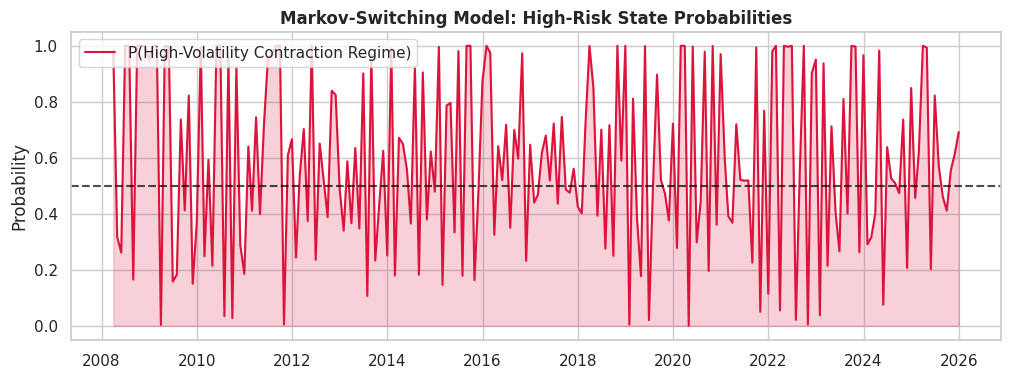

In [ ]:
# Estimate 2-Regime Model (order=1 drops the 1st row due to lagging)
model = MarkovAutoregression(
    endog=df_data['Equity'],
    k_regimes=2,
    order=1,
    exog=df_data[['Yield_Spread']],
    switching_variance=True
)

fit_res = model.fit(disp=False)

# Align index: statsmodels drops the first row for AR(1), so align with df_data.index[1:]
probs = fit_res.smoothed_marginal_probabilities
probs.index = df_data.index[1:]
probs.columns = ['Regime_0', 'Regime_1']

# Trim df_data to match the fitted probability timeframe
df_fitted = df_data.iloc[1:]

# Classify states by volatility (standard deviation of returns in each regime)
std_0 = df_fitted['Equity'][probs['Regime_0'] > 0.5].std()
std_1 = df_fitted['Equity'][probs['Regime_1'] > 0.5].std()

if std_1 > std_0:
    high_vol_idx, low_vol_idx = 1, 0
else:
    high_vol_idx, low_vol_idx = 0, 1

print(f"Low-Volatility Regime: State {low_vol_idx} (Monthly Vol: {min(std_0, std_1)*100:.2f}%)")
print(f"High-Volatility Regime: State {high_vol_idx} (Monthly Vol: {max(std_0, std_1)*100:.2f}%)")

# Plot smoothed regime probabilities
plt.figure(figsize=(12, 4))
plt.plot(probs[f'Regime_{high_vol_idx}'], color='crimson', label='P(High-Volatility Contraction Regime)')
plt.axhline(0.5, color='black', linestyle='--', alpha=0.7)
plt.fill_between(probs.index, 0, probs[f'Regime_{high_vol_idx}'], color='crimson', alpha=0.2)
plt.title('Markov-Switching Model: High-Risk State Probabilities', fontsize=12, fontweight='bold')
plt.ylabel('Probability')
plt.legend(loc='upper left')
plt.show()

# 5. Dynamic Portfolio Backtest Engine
We implement a dynamic rebalancing algorithm based on state probabilities:
- **P(High Risk) > 0.5:** Shift to defensive asset mix (20% Equity, 50% Bonds, 30% Gold)
- **P(High Risk) <= 0.5:** Shift to growth asset mix (70% Equity, 20% Bonds, 10% Gold)
A 15 bps (0.0015) rebalancing transaction cost is applied.

In [ ]:

assets = ['Equity', 'Bonds', 'Gold']
ret_data = df_data.iloc[1:][assets]  # Trim first row to match probs length

tc_bps = 15 / 10000.0  # 15 bps transaction cost penalty

# 1. Smooth the state probabilities with a 3-month rolling window to remove noise
smooth_prob_series = probs[f'Regime_{high_vol_idx}'].rolling(window=3, min_periods=1).mean()

strat_returns, bench_returns, weight_history = [], [], []

# Initial state & weights
current_state_is_high_risk = False
prev_w = np.array([0.70, 0.20, 0.10])    # Initial Aggressive Weight
bench_w = np.array([0.60, 0.40, 0.00])   # Benchmark 60/40 Weight

for t in range(len(ret_data)):
    p_high = smooth_prob_series.iloc[t]

    # 2. Hysteresis Logic (Dual Thresholds):
    # Only switch to HIGH RISK if probability exceeds 0.65
    # Only switch back to LOW RISK if probability drops below 0.35
    if current_state_is_high_risk:
        if p_high < 0.35:
            current_state_is_high_risk = False
    else:
        if p_high > 0.65:
            current_state_is_high_risk = True

    # Assign weights based on state
    if current_state_is_high_risk:
        target_w = np.array([0.20, 0.50, 0.30])  # Defensive
    else:
        target_w = np.array([0.70, 0.20, 0.10])  # Aggressive

    # Deduct transaction cost penalty on turnover
    turnover = np.sum(np.abs(target_w - prev_w))
    cost_penalty = turnover * tc_bps

    r_t = ret_data.iloc[t].values
    port_ret = np.dot(target_w, r_t) - cost_penalty
    bench_ret = np.dot(bench_w, r_t)

    strat_returns.append(port_ret)
    bench_returns.append(bench_ret)
    weight_history.append(target_w)
    prev_w = target_w

results_df = pd.DataFrame({'Strategy': strat_returns, 'Benchmark_60_40': bench_returns}, index=ret_data.index)
weights_df = pd.DataFrame(weight_history, index=ret_data.index, columns=assets)

print("Fixed Backtest complete with Hysteresis & Probability Smoothing.")

Fixed Backtest complete with Hysteresis & Probability Smoothing.


# 6. Performance Analytics & Dashboard
We compute annualized returns, annualized volatility, Sharpe ratio, and maximum drawdown,
and plot the dynamic asset weights alongside cumulative equity curves.

--- PORTFOLIO PERFORMANCE SUMMARY ---


,Strategy,Benchmark_60_40
Annual Return,6.33%,6.76%
Annual Volatility,10.34%,10.74%
Sharpe Ratio,0.59,0.61
Max Drawdown,-25.82%,-28.14%



--- MONTHLY REGIME & WEIGHT ALLOCATION (SAMPLE) ---


,Prob_High_Risk,Equity_Weight,Bonds_Weight,Gold_Weight,Strategy_Return,Benchmark_Return
2008-03-31,0.9827,20%,50%,30%,-1.06%,0.49%
2008-04-30,0.6500,20%,50%,30%,-1.59%,1.80%
2008-05-31,0.5205,20%,50%,30%,-0.87%,-0.45%
2008-06-30,0.5263,20%,50%,30%,0.84%,-4.25%
2008-07-31,0.7538,20%,50%,30%,-0.82%,-0.74%
2025-08-31,0.6176,20%,50%,30%,1.86%,1.14%
2025-09-30,0.4806,20%,50%,30%,5.96%,3.56%
2025-10-31,0.4759,20%,50%,30%,2.21%,1.91%
2025-11-30,0.5267,20%,50%,30%,1.75%,0.19%
2025-12-31,0.6200,20%,50%,30%,-0.71%,-1.10%


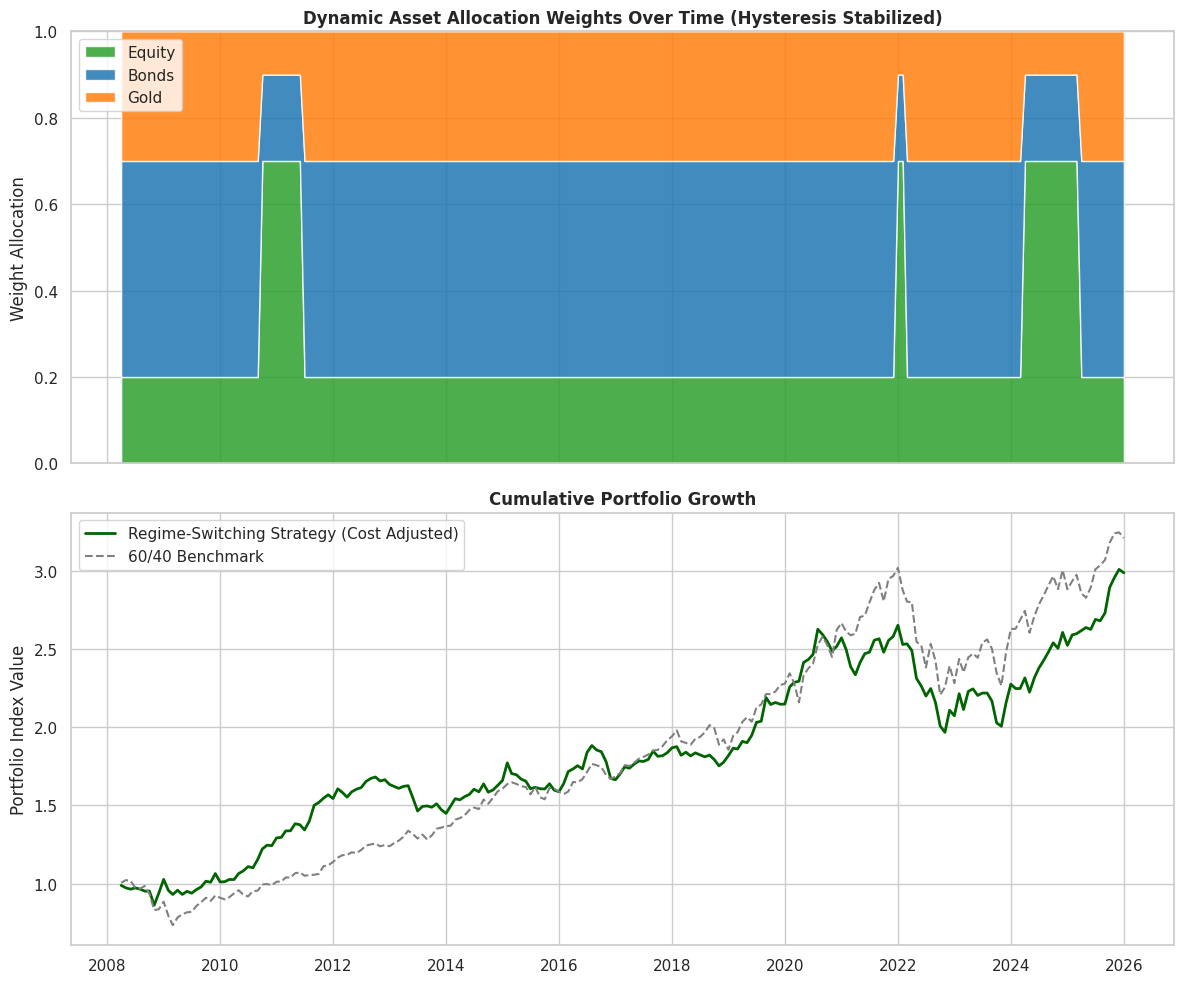

In [ ]:


# 1. Summary Performance Metrics Table
def compute_metrics(df):
    metrics = {}
    for col in df.columns:
        r = df[col]
        ann_ret = np.exp(r.sum() * (12 / len(r))) - 1
        ann_vol = r.std() * np.sqrt(12)
        sharpe = (r.mean() * 12) / ann_vol
        cum_ret = np.exp(r.cumsum())
        max_dd = ((cum_ret - cum_ret.cummax()) / cum_ret.cummax()).min()

        metrics[col] = {
            'Annual Return': f"{ann_ret*100:.2f}%",
            'Annual Volatility': f"{ann_vol*100:.2f}%",
            'Sharpe Ratio': f"{sharpe:.2f}",
            'Max Drawdown': f"{max_dd*100:.2f}%"
        }
    return pd.DataFrame(metrics)

print("--- PORTFOLIO PERFORMANCE SUMMARY ---")
summary_df = compute_metrics(results_df)
display(summary_df)

# 2. Detailed Allocation & Regime Table (First 10 & Last 10 Months)
allocation_table = pd.DataFrame({
    'Prob_High_Risk': smooth_prob_series.round(4),
    'Equity_Weight': (weights_df['Equity'] * 100).map('{:.0f}%'.format),
    'Bonds_Weight': (weights_df['Bonds'] * 100).map('{:.0f}%'.format),
    'Gold_Weight': (weights_df['Gold'] * 100).map('{:.0f}%'.format),
    'Strategy_Return': (np.exp(results_df['Strategy']) - 1).map('{:.2%}'.format),
    'Benchmark_Return': (np.exp(results_df['Benchmark_60_40']) - 1).map('{:.2%}'.format)
}, index=ret_data.index)

print("\n--- MONTHLY REGIME & WEIGHT ALLOCATION (SAMPLE) ---")
display(pd.concat([allocation_table.head(5), allocation_table.tail(5)]))

# 3. Visual Dashboard Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Stacked Area Plot of Dynamic Asset Weights
axes[0].stackplot(weights_df.index, weights_df['Equity'], weights_df['Bonds'], weights_df['Gold'],
                 labels=['Equity', 'Bonds', 'Gold'], colors=['#2ca02c', '#1f77b4', '#ff7f0e'], alpha=0.85)
axes[0].set_title('Dynamic Asset Allocation Weights Over Time (Hysteresis Stabilized)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Weight Allocation')
axes[0].legend(loc='upper left')
axes[0].set_ylim(0, 1)

# Cumulative Equity Growth Comparison
cum_strat = np.exp(results_df['Strategy'].cumsum())
cum_bench = np.exp(results_df['Benchmark_60_40'].cumsum())

axes[1].plot(cum_strat, color='darkgreen', linewidth=2, label='Regime-Switching Strategy (Cost Adjusted)')
axes[1].plot(cum_bench, color='grey', linestyle='--', label='60/40 Benchmark')
axes[1].set_title('Cumulative Portfolio Growth', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Portfolio Index Value')
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
# Save summary metrics and monthly history into a single Excel file
with pd.ExcelWriter('Macro_Regime_Portfolio_Results.xlsx') as writer:
    summary_df.to_excel(writer, sheet_name='Performance Metrics')
    allocation_table.to_excel(writer, sheet_name='Monthly Allocation History')
    results_df.to_excel(writer, sheet_name='Raw Monthly Returns')

print("[SUCCESS] Exported results to 'Macro_Regime_Portfolio_Results.xlsx'")

[SUCCESS] Exported results to 'Macro_Regime_Portfolio_Results.xlsx'
